In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_59000\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_59000\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

UnboundLocalError: cannot access local variable 'train_idx' where it is not associated with a value

[[-0.03013893 -0.02666184 -0.01336074 -0.02796177 -0.02276132 -0.05721253]
 [ 0.05587956  0.01620208 -0.11372207 -0.04281705 -0.12085642  0.05561394]
 [ 0.13945169  0.04554134 -0.0443523   0.092878   -0.33246969 -0.16240539]
 ...
 [ 0.12815799  0.08218821 -0.05393058  0.00437834 -0.0218441  -0.00337501]
 [ 0.05816739  0.01230751 -0.10682415 -0.02649304  0.10370839  0.06591273]
 [-0.01758097  0.0770755  -0.07962311  0.03667785  0.10638173 -0.05128432]]
[[-0.2806713   0.11028266  0.04358476]
 [-0.2539679   0.03486224 -0.02157575]
 [ 0.15078349  0.39526834 -0.05029367]
 [ 0.14967086 -0.12587871  0.44367176]
 [ 0.11449642  0.37245555 -0.10164067]
 [ 0.1650916  -0.0762311  -0.17467158]
 [ 0.10035257  0.51520589 -0.10936628]
 [ 0.06497691 -0.23559666 -0.36354456]
 [ 0.11268357 -0.05475308  0.40527996]
 [-0.00064096  0.03086842  0.08041917]
 [-0.14326319  0.0072414   0.06870808]
 [ 0.2460918   0.28948301 -0.01778461]
 [ 0.13359066 -0.23307418 -0.20076498]
 [ 0.17704794 -0.10175833  0.41054318

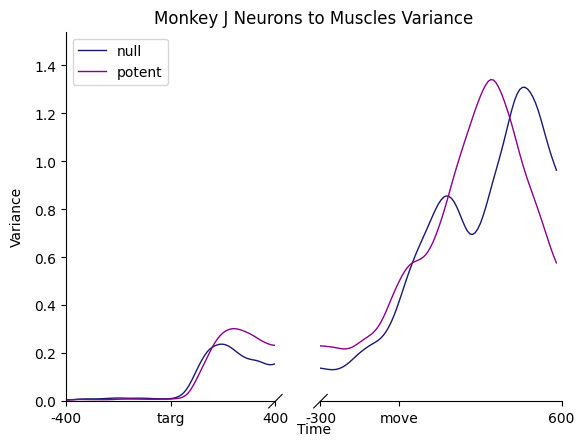

In [ ]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[[-0.11606209  0.0773366   0.0662828  ... -0.03542864  0.22817346
   0.10291752]
 [-0.0516239   0.05621971 -0.00539957 ... -0.02710166 -0.13924168
   0.05171072]
 [-0.05478754  0.1527312   0.00296787 ... -0.07848467 -0.00379379
  -0.01471771]
 ...
 [-0.02051586  0.02603307  0.09304186 ... -0.01148528 -0.0934755
   0.04369196]
 [-0.09009489  0.08493592  0.03081295 ...  0.09335121 -0.1976474
   0.01669485]
 [-0.04187857  0.04834952 -0.2266227  ... -0.02169797 -0.05949367
  -0.04609046]]
[[-4.06440573e-02 -4.13776958e-02  8.45061729e-02 -7.89488781e-02
   6.58894521e-02 -4.30276303e-02  1.29508168e-01]
 [ 1.59631077e-02 -1.98884232e-02 -7.76192360e-03  5.18647713e-02
  -1.70002423e-02  8.29374732e-02  5.20050644e-02]
 [ 3.89972915e-02 -1.65192992e-01  7.29249547e-02  8.31168552e-02
  -4.93507292e-02  1.86962652e-02  3.40997607e-02]
 [ 7.40902304e-02 -2.99351468e-02 -3.51175594e-02  2.41674654e-01
  -7.49377785e-02  1.45734170e-01  1.22069161e-01]
 [ 6.21065941e-02  1.47398456e-02  1.52683

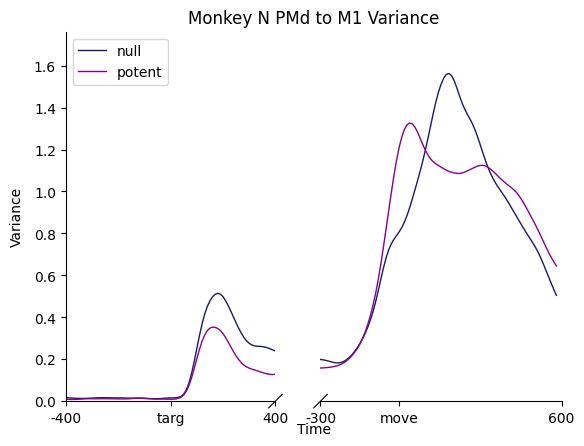

In [ ]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[[-0.02647275 -0.03037914 -0.03582846 ...  0.03216829 -0.11653916
   0.07318577]
 [ 0.08982139 -0.0707322  -0.20377211 ... -0.06760347 -0.15328034
   0.0425051 ]
 [ 0.20112578 -0.03541444 -0.05352147 ...  0.14850866  0.07036551
   0.10691937]
 ...
 [ 0.15973314  0.08726125  0.07243    ...  0.08151365  0.11189968
   0.0114798 ]
 [-0.0827277   0.00905804 -0.09371463 ...  0.05992633  0.16666839
  -0.22084601]
 [ 0.10962166  0.02147509  0.00662554 ...  0.08479353  0.03760668
   0.06466063]]
[[-1.39055905e-01 -1.40818714e-01  4.17316313e-02 -4.38061205e-02
   3.24134189e-02 -1.62463440e-01  4.36878545e-02]
 [-4.54707955e-02 -4.30279307e-02  4.85973210e-02  1.56128115e-02
  -1.26152634e-02  7.72648098e-03  1.77663858e-02]
 [ 1.16535954e-01 -8.27356201e-02  2.87755011e-02 -8.03808124e-02
  -1.50219056e-02  1.40858515e-01 -6.66606654e-02]
 [ 3.26471759e-02  8.06265478e-03  6.02761433e-02 -4.48712368e-02
  -8.79977571e-03 -2.04975372e-03  4.62491946e-02]
 [ 1.57034147e-02  5.93164486e-02  5.658

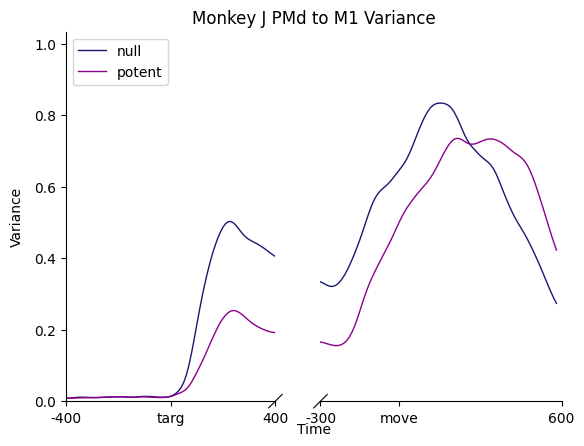

In [ ]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[[-0.02647275 -0.03037914 -0.03582846 ...  0.03216829 -0.11653916
   0.07318577]
 [ 0.08982139 -0.0707322  -0.20377211 ... -0.06760347 -0.15328034
   0.0425051 ]
 [ 0.20112578 -0.03541444 -0.05352147 ...  0.14850866  0.07036551
   0.10691937]
 ...
 [ 0.15973314  0.08726125  0.07243    ...  0.08151365  0.11189968
   0.0114798 ]
 [-0.0827277   0.00905804 -0.09371463 ...  0.05992633  0.16666839
  -0.22084601]
 [ 0.10962166  0.02147509  0.00662554 ...  0.08479353  0.03760668
   0.06466063]]
[[-1.39055905e-01 -1.40818714e-01  4.17316313e-02 -4.38061205e-02
   3.24134189e-02 -1.62463440e-01  4.36878545e-02]
 [-4.54707955e-02 -4.30279307e-02  4.85973210e-02  1.56128115e-02
  -1.26152634e-02  7.72648098e-03  1.77663858e-02]
 [ 1.16535954e-01 -8.27356201e-02  2.87755011e-02 -8.03808124e-02
  -1.50219056e-02  1.40858515e-01 -6.66606654e-02]
 [ 3.26471759e-02  8.06265478e-03  6.02761433e-02 -4.48712368e-02
  -8.79977571e-03 -2.04975372e-03  4.62491946e-02]
 [ 1.57034147e-02  5.93164486e-02  5.658

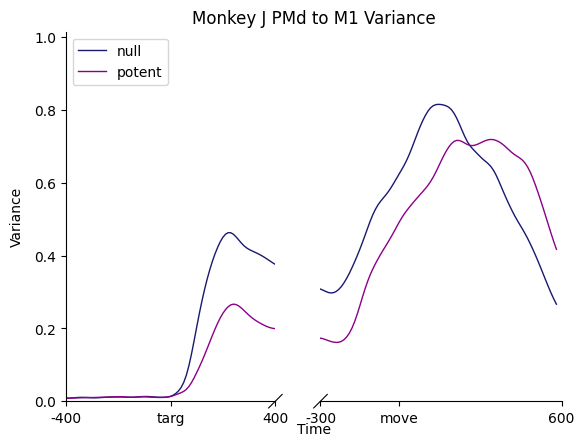

In [ ]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[[-0.07587527  0.0209299   0.02814072  0.00262266 -0.0024848   0.02483276]
 [-0.03523845  0.01561448 -0.00088601  0.02520756  0.00750897  0.06001764]
 [-0.04644422  0.08579143  0.01730417  0.02155867 -0.00703983  0.05661994]
 ...
 [-0.07132808  0.15107716 -0.03114864 -0.03010715 -0.03911884 -0.07654768]
 [ 0.01924013 -0.0095101  -0.07442662  0.08981851  0.00048923  0.01366145]
 [ 0.03216836  0.12162016 -0.02060084 -0.04303541  0.0030302  -0.07849461]]
[[-0.29123038  0.25897305  0.18346179]
 [-0.08978452 -0.4661521   0.52193719]
 [-0.38185672  0.09755625  0.11716735]
 [-0.07874426 -0.39468499 -0.43271778]
 [-0.41560395 -0.08297143 -0.20103602]
 [-0.00371851 -0.23744972 -0.3653738 ]
 [-0.32090671 -0.34845012 -0.05243019]
 [ 0.02221486 -0.0258204   0.24271046]
 [-0.37782215  0.31402705  0.16819719]
 [-0.03853731 -0.50743615  0.35437966]
 [-0.40934802  0.07544605  0.10552652]
 [-0.40876986 -0.05651874 -0.30392204]]
>>> best_lam returning: 0.0001


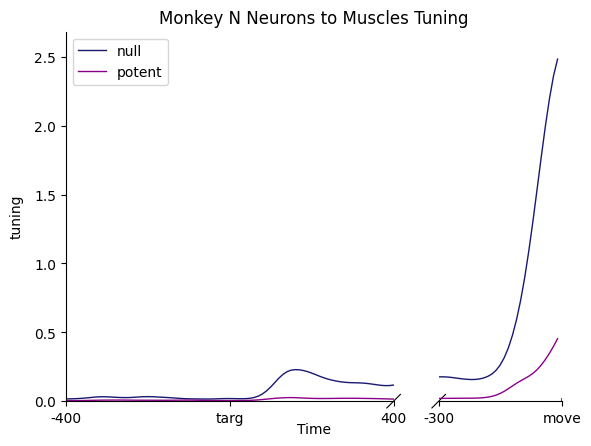

In [ ]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [ ]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)